# 딥러닝-성능 최적화: 과적합 방지

FashionMNIST 데이터를 사용해 CNN 모델의 과적합을 확인하고, Early Stopping과 Dropout으로 과적합을 줄이는 방법을 실습합니다.

이 노트북의 목표는 다음과 같습니다.

- 복잡한 CNN 모델에서 train loss와 validation loss의 차이를 확인한다.
- Early Stopping으로 validation 성능이 더 이상 좋아지지 않을 때 학습을 멈춘다.
- 가장 좋은 validation loss를 보인 모델을 저장하고 다시 불러온다.
- Dropout을 적용해 과적합을 완화한다.
- Dropout 비율과 Early Stopping 설정을 바꿔 성능 변화를 비교한다.

## 1. 환경 준비

- 필요한 라이브러리를 불러오고, 반복해서 사용할 함수들을 먼저 정의합니다.

### 1.1 라이브러리 불러오기

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [4]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

- 모델 요약 도구
    - `torchsummary`가 설치되어 있으면 CNN 레이어별 출력 크기와 파라미터 수를 확인할 수 있습니다.

In [5]:
# 설치가 필요한 경우 라이브러리 설치합니다.
# %pip install torchsummary

In [6]:
from torchsummary import summary

### 1.2 필요 함수 생성

아래 함수들이 학습 흐름의 핵심입니다.

- `make_DataSet`: numpy/pandas 데이터를 학습용 `DataLoader`와 검증 텐서로 변환합니다.
- `train`: 한 epoch 동안 미니배치 학습을 수행합니다.
- `evaluate`: 검증 또는 테스트 데이터 전체에 대해 손실과 예측값을 반환합니다.
- `dl_learning_curve`: train loss, validation loss, validation accuracy를 시각화합니다.

- `make_DataSet` 함수 : 딥러닝을 위한 데이터로더 만들기

In [7]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
    """pandas/numpy 데이터를 PyTorch 학습용 DataLoader와 검증 텐서로 변환합니다."""

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(np.array(x_train), dtype=torch.float32)
    y_train_tensor = torch.tensor(np.array(y_train), dtype=torch.long)
    x_val_tensor = torch.tensor(np.array(x_val), dtype=torch.float32)
    y_val_tensor = torch.tensor(np.array(y_val), dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, x_val_tensor, y_val_tensor

- `train` 함수 : 학습을 위한 함수

In [8]:
def train(dataloader, model, loss_fn, optimizer, device):
    """한 epoch 동안 모델을 학습하고 평균 train loss를 반환합니다."""
    model.train()                               # 훈련 모드로 설정
    total_loss = 0

    for x, y in dataloader:                # (x, y) : 입력 데이터와 레이블
        x, y = x.to(device), y.to(device)  # 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Feed Forward
        optimizer.zero_grad()              # 이전 배치의 gradient를 초기화
        pred = model(x)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()                    # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()                   # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트

        total_loss += loss.item() * x.size(0)  # 배치 평균 loss에 배치 크기를 곱해 배치 전체 loss로 누적

    return total_loss / len(dataloader.dataset)  # 전체 데이터 개수로 나누어 epoch 평균 loss 반환

- `evaluate` 함수 : 검증을 위한 함수

In [9]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    """검증/테스트 데이터 전체에 대한 loss와 예측값을 반환합니다."""

    model.eval()  # 모델을 평가 모드로 설정

    with torch.no_grad():  # 평가 과정에서는 기울기를 계산하지 않음
        x = x_val_tensor.to(device)
        y = y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()

    return eval_loss, pred

- 학습 곡선

In [10]:
def dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list):
    epochs = range(1, len(tr_loss_list) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, tr_loss_list, label="train_loss", marker=".")
    plt.plot(epochs, val_loss_list, label="val_loss", marker=".")
    plt.plot(epochs, val_acc_list, label="val_acc", marker=".")
    plt.xlabel("Epoch")
    plt.ylabel("Loss / Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

- 예측 결과 변환 함수

In [11]:
def predict_class(pred):
    """모델 출력(logits)을 최종 클래스 번호로 변환합니다."""
    pred_prob = nn.functional.softmax(pred, dim=1)
    return np.argmax(pred_prob.cpu().numpy(), axis=1)

- 모델 평가 함수

In [12]:
def evaluate_report(x_test, y_test, model, loss_fn, device, classes):
    """테스트 데이터 예측 후 confusion matrix와 classification report를 출력합니다."""

    _, pred = evaluate(x_test, y_test, model, loss_fn, device)
    pred = predict_class(pred)

    cm = confusion_matrix(y_test.numpy(), pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot()
    plt.xticks(rotation=90)
    plt.show()

    print("=" * 80)
    print(f"Accuracy : {accuracy_score(y_test.numpy(), pred)}")
    print("-" * 80)
    print(classification_report(y_test.numpy(), pred, target_names=classes))

    return pred

### 1.3 Device 준비

GPU가 있으면 GPU를 사용하고, 없으면 CPU를 사용합니다.

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### 1.4 데이터 셋

- FashionMNIST는 10가지 패션 아이템 이미지 분류 데이터입니다.

    - 입력 데이터: 28 x 28 흑백 이미지
    - 정답 데이터: 패션 아이템 클래스 0 ~ 9
    - 클래스 개수: 10개

![](https://www.researchgate.net/publication/346405197/figure/fig3/AS:962581560848384@1606508736352/Examples-of-Fashion-MNIST-dataset.ppm)

- 데이터 다운로드

In [14]:
train_dataset = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor())
test_dataset = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 166kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.23MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.2MB/s]


- 데이터 축소
    - 여러 실험을 반복하기 위해 학습 데이터 크기를 줄여서 진행합니다.

In [15]:
# 데이터와 레이블 추출
train_data = train_dataset.data.numpy() / 255
train_labels = train_dataset.targets.numpy()
test_data = test_dataset.data.numpy() / 255
test_labels = test_dataset.targets.numpy()

# 데이터 샘플링 : 클래스 비율을 유지하기 위해 stratify 사용
x_train, _, y_train, _ = train_test_split(
    train_data,
    train_labels,
    test_size=40000,
    random_state=10,
    stratify=train_labels
)
x_val, x_test, y_val, y_test = train_test_split(
    test_data,
    test_labels,
    test_size=5000,
    random_state=10,
    stratify=test_labels
)

# 3차원 데이터를 CNN 입력 형태인 4차원으로 변환
x_train = x_train.reshape(20000, 1, 28, 28)
x_val = x_val.reshape(5000, 1, 28, 28)
x_test = x_test.reshape(5000, 1, 28, 28)

# tensor로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
x_val = torch.tensor(x_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# train_dataset으로 변환
train_TensorDS = TensorDataset(x_train, y_train)

- 데이터셋의 x와 y

In [16]:
x_train.shape, y_train.shape

(torch.Size([20000, 1, 28, 28]), torch.Size([20000]))

- y(target)의 클래스

In [17]:
classes = train_dataset.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

- train은 DataLoader로 생성

In [18]:
batch_size = 64
train_dataloader = DataLoader(train_TensorDS, batch_size=batch_size, shuffle=True)

In [19]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_dataloader:
    print(f"Shape of x [batch, channels, height, width]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [batch, channels, height, width]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## 2. 모델링: 과적합

- 모델링의 목적은 학습 데이터에만 잘 맞는 모델이 아니라, 보지 못한 데이터도 잘 예측하는 모델을 만드는 것입니다.

    - 너무 단순한 모델: train, validation 성능이 모두 낮음
    - 적절히 복잡한 모델: train, validation 성능이 함께 개선됨
    - 너무 복잡한 모델: train 성능은 높지만 validation 성능이 떨어질 수 있음

- 딥러닝에서 과적합을 조절하는 대표 방법은 다음과 같습니다.

    - epoch와 learning rate 조정
    - hidden layer 수와 node 수 조정
    - Early Stopping
    - Dropout
    - 가중치 규제(L1, L2)

### 2.1 모델 선언

In [20]:
n_class = 10

# 모델 구조 설계
model1 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),    # 7의 반으로 줄어들 때, 3으로 계산
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model1.parameters(), lr=0.001)

summary(model1, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
              ReLU-8            [-1, 128, 7, 7]               0
         MaxPool2d-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                  [-1, 128]         147,584
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
             ReLU-14                   

### 2.2 모델 학습

Epoch 1, train loss : 0.7726, val loss : 0.5725, val acc : 0.7818
Epoch 2, train loss : 0.4689, val loss : 0.4915, val acc : 0.8330
Epoch 3, train loss : 0.3860, val loss : 0.4038, val acc : 0.8458
Epoch 4, train loss : 0.3382, val loss : 0.3769, val acc : 0.8604
Epoch 5, train loss : 0.3052, val loss : 0.3279, val acc : 0.8824
Epoch 6, train loss : 0.2766, val loss : 0.3167, val acc : 0.8894
Epoch 7, train loss : 0.2614, val loss : 0.3577, val acc : 0.8784
Epoch 8, train loss : 0.2361, val loss : 0.3240, val acc : 0.8872
Epoch 9, train loss : 0.2199, val loss : 0.3271, val acc : 0.8888
Epoch 10, train loss : 0.2008, val loss : 0.3083, val acc : 0.8930
Epoch 11, train loss : 0.1893, val loss : 0.3187, val acc : 0.8954
Epoch 12, train loss : 0.1757, val loss : 0.3157, val acc : 0.8932
Epoch 13, train loss : 0.1601, val loss : 0.3273, val acc : 0.8998
Epoch 14, train loss : 0.1460, val loss : 0.3126, val acc : 0.9008
Epoch 15, train loss : 0.1277, val loss : 0.3168, val acc : 0.8980
Epoc

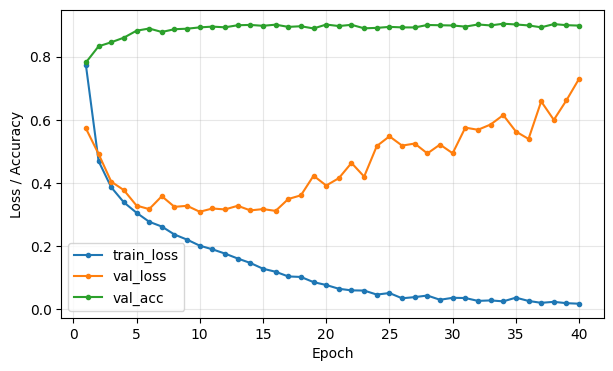

In [21]:
epochs = 40
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model1, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model1, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### 2.3 모델 평가

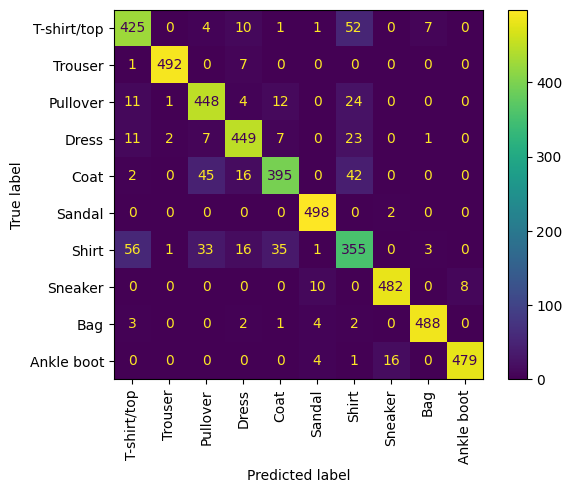

Accuracy : 0.9022
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84       500
     Trouser       0.99      0.98      0.99       500
    Pullover       0.83      0.90      0.86       500
       Dress       0.89      0.90      0.89       500
        Coat       0.88      0.79      0.83       500
      Sandal       0.96      1.00      0.98       500
       Shirt       0.71      0.71      0.71       500
     Sneaker       0.96      0.96      0.96       500
         Bag       0.98      0.98      0.98       500
  Ankle boot       0.98      0.96      0.97       500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



In [22]:
pred = evaluate_report(x_test, y_test, model1, loss_fn, device, classes)

---

## 3. 모델링: Early Stopping

- Early Stopping은 validation 성능이 더 이상 개선되지 않을 때 학습을 조기에 멈추는 기법입니다.

    - 과적합을 방지할 수 있음
    - 불필요한 epoch 실행을 줄일 수 있음
    - `patience`는 성능이 개선되지 않아도 기다릴 epoch 수

### 3.1 모델 선언

In [23]:
n_class = 10

# 모델 구조 설계
model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters(), lr=0.001)

summary(model2, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Conv2d-7            [-1, 128, 7, 7]          73,856
              ReLU-8            [-1, 128, 7, 7]               0
         MaxPool2d-9            [-1, 128, 3, 3]               0
          Flatten-10                 [-1, 1152]               0
           Linear-11                  [-1, 128]         147,584
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 64]           8,256
             ReLU-14                   

### 3.2 모델 학습

In [24]:
epochs = 40
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정
patience = 3
best_loss = float("inf")            # 초기값을 무한대로 설정
counter = 0
# -----------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model2, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인-----------------------------------------------
    if val_loss > best_loss:
        counter += 1
        print(f"===> early stopping, best_loss : {best_loss:.4f}, counter : {counter}")
    else:
        best_loss = val_loss
        counter = 0

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!!")
        break
    # -----------------------------------------------------------------

Epoch 1, train loss : 0.8394, val loss : 0.5926, val acc : 0.7646
Epoch 2, train loss : 0.5002, val loss : 0.5025, val acc : 0.8152
Epoch 3, train loss : 0.4069, val loss : 0.4042, val acc : 0.8488
Epoch 4, train loss : 0.3548, val loss : 0.3686, val acc : 0.8654
Epoch 5, train loss : 0.3262, val loss : 0.3383, val acc : 0.8740
Epoch 6, train loss : 0.2930, val loss : 0.3206, val acc : 0.8832
Epoch 7, train loss : 0.2678, val loss : 0.3324, val acc : 0.8816
===> early stopping, best_loss : 0.3206, counter : 1
Epoch 8, train loss : 0.2455, val loss : 0.2990, val acc : 0.8938
Epoch 9, train loss : 0.2316, val loss : 0.2920, val acc : 0.8964
Epoch 10, train loss : 0.2129, val loss : 0.2900, val acc : 0.8956
Epoch 11, train loss : 0.1892, val loss : 0.3085, val acc : 0.8886
===> early stopping, best_loss : 0.2900, counter : 1
Epoch 12, train loss : 0.1786, val loss : 0.3117, val acc : 0.8922
===> early stopping, best_loss : 0.2900, counter : 2
Epoch 13, train loss : 0.1626, val loss : 0.30

- 학습 곡선

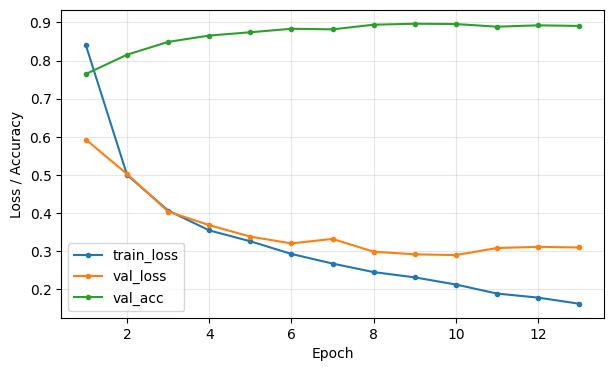

In [25]:
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### 3.3 모델 평가

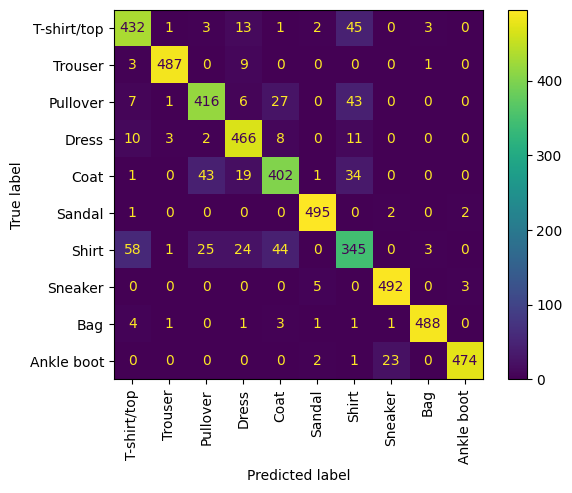

Accuracy : 0.8994
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.86      0.85       500
     Trouser       0.99      0.97      0.98       500
    Pullover       0.85      0.83      0.84       500
       Dress       0.87      0.93      0.90       500
        Coat       0.83      0.80      0.82       500
      Sandal       0.98      0.99      0.98       500
       Shirt       0.72      0.69      0.70       500
     Sneaker       0.95      0.98      0.97       500
         Bag       0.99      0.98      0.98       500
  Ankle boot       0.99      0.95      0.97       500

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



In [27]:
pred = evaluate_report(x_test, y_test, model2, loss_fn, device, classes)

### 3.4 모델 저장

- Early Stopping을 사용할 때 validation loss가 가장 좋은 모델을 저장해 두면, 마지막 epoch의 모델 대신 최적 시점의 모델을 사용할 수 있습니다.

#### 3.4.1 모델 선언

In [ ]:
n_class = 10

# 모델 구조 설계
model3 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters(), lr=0.001)

summary(model3, input_size=(1, 28, 28))

#### 3.4.2 모델 학습 및 저장

In [ ]:
epochs = 20
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정
patience = 3
best_loss = float("inf")            # 초기값을 무한대로 설정
counter = 0

# 모델 저장 경로
PATH = './best_model.pt'

for t in range(epochs):
    tr_loss = train(train_dataloader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model3, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인
    if val_loss > best_loss:
        counter += 1
        print(f"--> early stopping status, best_loss : {best_loss:.4f}, counter : {counter}")
    else:
        best_loss = val_loss
        counter = 0
        torch.save(model3, PATH)  # best model 저장

    # 조기 종료 조건 확인
    if counter >= patience:
        print("Early Stopping!")
        break

#### 3.4.3 저장된 모델 사용

- 모델 로딩

In [ ]:
best_model = torch.load(PATH, map_location=device, weights_only=False)
best_model = best_model.to(device)

- 예측

In [ ]:
pred = evaluate_report(x_test, y_test, best_model, loss_fn, device, classes)

---

## 4. 모델링: Dropout

- Dropout은 과적합을 방지하는 정규화 기법 중 하나입니다.
- 학습 중 일부 뉴런을 무작위로 비활성화하여 특정 뉴런 조합에 지나치게 의존하지 않도록 만듭니다.

    - convolution block 뒤에는 `Dropout2d`를 사용
    - dense layer 뒤에는 `Dropout`을 사용
    - 출력층 뒤에는 Dropout을 적용하지 않음

### 4.1 Dropout 추가

- 모델 선언

In [ ]:
n_class = 10
dropout_rate = 0.3 # 보통 0.2~0.5 사이에서 조정. hidden layer의 노드 중 30%를 임의로 제외

# 모델 구조 설계
model4 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),

    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(128 * 3 * 3, 128),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),     # Dense Layer 후 드롭아웃 추가

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),

    nn.Linear(64, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model4.parameters(), lr=0.001)

summary(model4, input_size=(1, 28, 28))

### 4.2 모델 학습

In [ ]:
epochs = 40
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model4, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model4, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

### 4.3 모델 평가

In [ ]:
pred = evaluate_report(x_test, y_test, model4, loss_fn, device, classes)

---

## 5. 실습

- 드롭아웃 비율을 조절하면서 모델 성능을 살펴봅니다.

    - dropout rate: `0.1`, `0.2`, `0.3`, `0.5`
    - Early Stopping patience: `1`, `3`, `5`, `10`

### 5.1 과적합 확인

#### 5.1.1 모델 선언

- `2. 모델링: 과적합`보다 더 복잡한 모델을 선언합니다.
    - 노드수, 레이어 수를 늘립니다.

In [ ]:
n_class = 10
dropout_rate = 0.1 # 보통 0.2~0.5 사이에서 조정. hidden layer의 노드 중 30%를 임의로 제외

# 모델 구조 설계
model5 = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),
    nn.Conv2d(8, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),
    nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Dropout2d(p=dropout_rate),

    nn.Flatten(),
    nn.Linear(256 * 3 * 3, 256),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),

    nn.Linear(256, 8),
    nn.ReLU(),
    nn.Dropout(p=dropout_rate),

    nn.Linear(8, n_class)
).to(device)

# loss, optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model5.parameters(), lr=0.001)

summary(model5, input_size=(1, 28, 28))

#### 5.1.2 모델 학습

- epochs = 30으로 학습 시도

In [ ]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model5, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model5, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 5.1.3 모델 평가

In [ ]:
pred = evaluate_report(x_test, y_test, model5, loss_fn, device, classes)

### 5.2 Early Stopping

#### 5.2.1 모델 선언

- `5.1`의 과적합 모델을 그대로 사용합니다.

#### 5.2.2 모델 학습
- epochs = 30으로 학습시도
- Early Stopping 설정
    - patience 조정 : 1, 3, 5, 10

In [ ]:
epochs =
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정 ----------------



# ------------------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

    # early stopping 확인 -------------------



    # ----------------------------------------

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

#### 5.2.3 모델 평가

In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)

### 5.3 Dropout

#### 5.3.1 Dropout 비율 조정하며 학습 곡선 확인하기

- `5.1`의 과적합 모델에 Dropout을 추가합니다.

- 설계

- 학습
    - epochs = 30으로 학습시도

In [ ]:
epochs =
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)

- Dropout 비율을 바꿔 다시 설계

- 학습

In [ ]:
epochs =
tr_loss_list, val_loss_list, val_acc_list = [], [], []

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)

#### 5.3.2 [추가] Dropout + Early Stopping

- 다음 설정을 함께 적용합니다.

    - dropout rate: `0.3`
    - early stopping patience: `3`

- 모델 설계

In [ ]:
epochs = 30
tr_loss_list, val_loss_list, val_acc_list = [], [], []

# early stopping을 위한 변수 설정 ----------------



# ------------------------------------------------

for t in range(epochs):
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val, y_val, model, loss_fn, device)

    # accuracy 측정
    pred = predict_class(pred)
    acc = accuracy_score(y_val.numpy(), pred)

    # 리스트에 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_acc_list.append(acc)

    print(f"Epoch {t+1}, train loss : {tr_loss:.4f}, val loss : {val_loss:.4f}, val acc : {acc:.4f}")


    # early stopping 확인 -------------------



    # ----------------------------------------

# 학습곡선
dl_learning_curve(tr_loss_list, val_loss_list, val_acc_list)

- 모델 평가

In [ ]:
pred = evaluate_report(x_test, y_test, model, loss_fn, device, classes)